In [1]:
import os
WORK_DIR = os.getcwd()
PATH_OF_SRC_MODUL = WORK_DIR.replace("notebooks", "src")
YOUR_DATA_PATH = r"\\sc-data.sc-store.charite.de\sc-project-cc06-agsack\noja11\CellTrack\unregistered\1mpf and 2mpf\1mpf and 2mpf"
OUTPUT_PATH = r"\\sc-data.sc-store.charite.de\sc-project-cc06-agsack\noja11\CellTrack\unregistered\output"
IMAGE_CHANNEL = 1

In [2]:
import sys
sys.path.append(PATH_OF_SRC_MODUL)
import algo_funcs as algo
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [3]:
IMAGE_PATHS_PATTERN = rf'{YOUR_DATA_PATH}/lck-mCherry_cd79b-GFP__DOB_5-6-25_2mpf_Fish-3_anal-fin_.tif'
algo.IMAGE_CHANNEL = IMAGE_CHANNEL
DATASET_NAME = os.path.splitext(os.path.basename(IMAGE_PATHS_PATTERN))[0]
os.makedirs(OUTPUT_PATH,exist_ok=True)

In [4]:
import tifffile

images = tifffile.imread(IMAGE_PATHS_PATTERN)
images = list(np.moveaxis(images, 1, -1)) 
print(len(images), images[0].shape)

600 (512, 512, 3)


In [5]:
images_unchanged = [img.copy() for img in images]

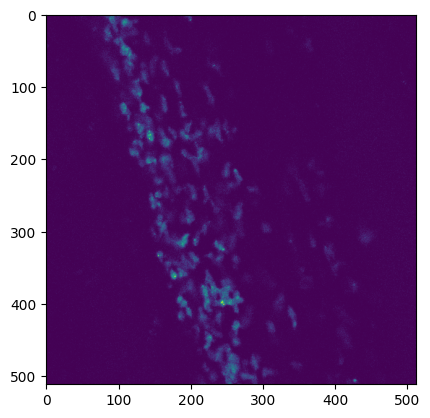

In [6]:
CELL_SIZE = 30
plt.imshow(images_unchanged[0][...,IMAGE_CHANNEL])

In [16]:
images = [img.copy() for img in images_unchanged]

In [17]:
#images = algo.bm3d_denoise_all(images = images)
#images = algo.clip_images(images = images, clip_percentile=99)
#images = algo.log_transform_all(images=images)
#images = algo.median_denoise_all(images = images, size = 5)
images = algo.monogenic_filter_images(images = images, cw=2, sigma_onf=0.1, sigma_smooth=1)
#images = algo.wavelet_denoise_images_all(images = images)
#images = algo.unsharp_mask_all(images = images, radius = 10, amount =1)

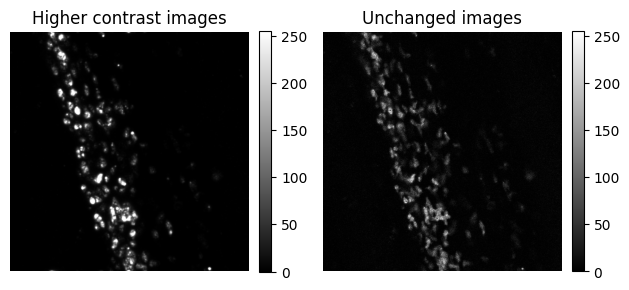

In [18]:
fig, axes = plt.subplots(1, 2)
frame = 0

im1 = axes[0].imshow(np.array(images[frame][..., IMAGE_CHANNEL], dtype=np.uint8),
    cmap='gray')
axes[0].set_title('Higher contrast images')
axes[0].axis('off')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

im2 = axes[1].imshow(np.array(images_unchanged[frame][..., IMAGE_CHANNEL], dtype=np.uint8),
    cmap='gray')
axes[1].set_title('Unchanged images')
axes[1].axis('off')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(rf"{OUTPUT_PATH}/contrast_enh.png", bbox_inches='tight')

In [ ]:
#edges_list, mask_list, labels_list = algo.locate_all_cells_centroids(images = images, cell_size = CELL_SIZE, min_distance = CELL_SIZE)
edges_list, mask_list, labels_list = algo.locate_all_cells_centroids_voronoi_otsu(images = images, spot_sigma= 3, outline_sigma = 3)

Text(0, 0.5, 'Number of detected Cells')

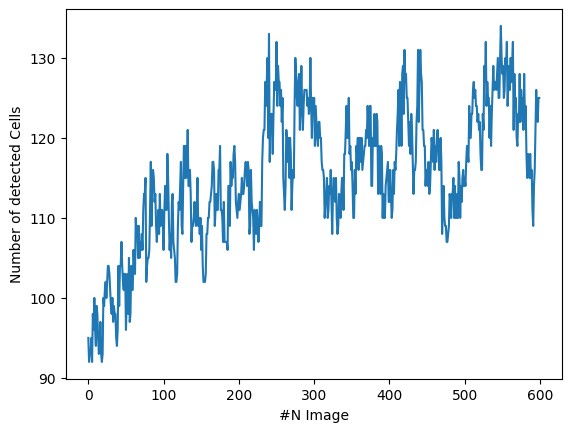

In [11]:
num_edges = [len(edges) for edges in edges_list]

plt.plot(num_edges)
plt.xlabel("#N Image")
plt.ylabel("Number of detected Cells")

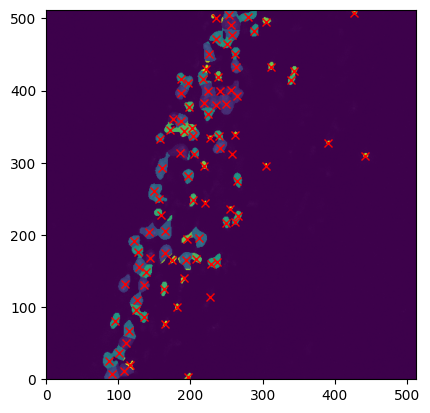

In [12]:
frame = 0
zoom_x = (0,images[frame].shape[0])
zoom_y = (0,images[frame].shape[1])

plt.imshow(np.array(images[frame][..., IMAGE_CHANNEL],dtype=np.uint8),
    cmap='gray')
plt.imshow(mask_list[frame],alpha=0.9)
edges = edges_list[frame]
for edge in edges:
    plt.plot(edge[0], edge[1], 'rx') 
plt.xlim(zoom_x)
plt.ylim(zoom_y)
plt.savefig(rf"{OUTPUT_PATH}/detected_cells.png", bbox_inches='tight')

In [13]:
frame_width = images_unchanged[0].shape[1]
frame_height = images_unchanged[0].shape[0]
fps = 10  # Frames per second
output_video = cv2.VideoWriter(f"{OUTPUT_PATH}/detected_edges.mp4", cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

# Iterate through the unsharp_mask frames and edges
for frame_idx in range(0, len(images_unchanged)):
    img = images_unchanged[frame_idx]  
    
    img = np.array(img,dtype=np.uint8)
    
    img = cv2.resize(img, (frame_width, frame_height))
    
    img_bgr = img

    edges = edges_list[frame_idx]
    for edge in edges:
        x, y = int(edge[0]), int(edge[1]) 
        cv2.circle(img_bgr, (x, y), 5, (0, 0, 255), -1)

    cv2.putText(img_bgr, f"Frame {frame_idx}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    output_video.write(img_bgr)

output_video.release()

In [14]:
dict_list_original, average_flow, tracked_mask_original, flows = algo.track_points_optical_flow(
    images=np.array(images_unchanged, dtype=np.uint8),
    all_points=edges_list,
    all_labels=labels_list,
    labeled_masks=mask_list,
    max_distance=CELL_SIZE/2,
    max_occlusion_frames=5,
)

Working on image: 0
Working on image: 1
Working on image: 2
Working on image: 3
Working on image: 4
Working on image: 5
Working on image: 6
Working on image: 7
Working on image: 8
Working on image: 9
Working on image: 10
Working on image: 11
Working on image: 12
Working on image: 13
Working on image: 14
Working on image: 15
Working on image: 16
Working on image: 17
Working on image: 18
Working on image: 19
Working on image: 20
Working on image: 21
Working on image: 22
Working on image: 23
Working on image: 24
Working on image: 25
Working on image: 26
Working on image: 27
Working on image: 28
Working on image: 29
Working on image: 30
Working on image: 31
Working on image: 32
Working on image: 33
Working on image: 34
Working on image: 35
Working on image: 36
Working on image: 37
Working on image: 38
Working on image: 39
Working on image: 40
Working on image: 41
Working on image: 42
Working on image: 43
Working on image: 44
Working on image: 45
Working on image: 46
Working on image: 47
Wo

In [15]:
import ctc_reformat as ctc
os.makedirs(rf"{OUTPUT_PATH}/".replace("*",""),exist_ok=True)
np.save(rf"{OUTPUT_PATH}/calc_paths.npy".replace("*",""),  dict_list_original) 
#ctc.save_track_data_to_file(dict_list_original, tracked_mask_original,rf"{OUTPUT_PATH}".replace("*",""))
#algo.save_images(images = images, directory = rf"{OUTPUT_PATH}".replace("*",""), pattern = f"{DATASET_NAME}".replace("*",""))